# Gettting Started with neuraLQX

*Author: Waleed Sherif (FAU Erlangen-Nürnberg)*

In this tutorial, we introduce the basic structure and usage of the [neuraLQX](https://www.github.com/waleed-sh/neuralqx) package. Specifically, we will see how to build graphs, how to build Hilbert spaces, LQG models, Solvers and more.

This basic quick start is supposed to help you understand the upcoming tutorials

## 0.0 Installing neuraLQX

The first step is installing neuraLQX. This can be done using ``pip`` by executing the following command in your terminal/command line tool:

`>>> pip install --upgrade pip`


`>>> pip install neuralqx`

Once installed, you can simply import `neuralqx` in your Jupyter or python script as

In [1]:
import neuralqx as nqx

The package is structured that it has several modules within it, each responsible for certain task. Some of those modules are purely for internal purposes (e.g. ensures that the neuraLQX package runs as it should) while some of them are ones which you will use often. We will discuss the latter in what follows.

## 1.0 The graph module

Currently, neuraLQX only supports graph preserving LQG. Therefore, our starting point is to always define our fixed graph. The `graph` houses the `GraphHandler` object. This object will include within it any functionalities which are graph dependent and it will also include within it different implementations of your graph. Let us now go through these functionalities, but first, how do we define a graph?

In our implementation, vertices of a graph are labeled by positive integers `a, b, c, ...`. Edges are directed and are just (python) lists of vertices which they emanate from to the ones they are incident at. For example, `[a, b]` is a directed edge emanating from the vertex `a` and incident at `b`.

To create a `GraphHandler` object, all you have to do is specify to it the list of directed edges which constitute your graph. This can be done as follows.

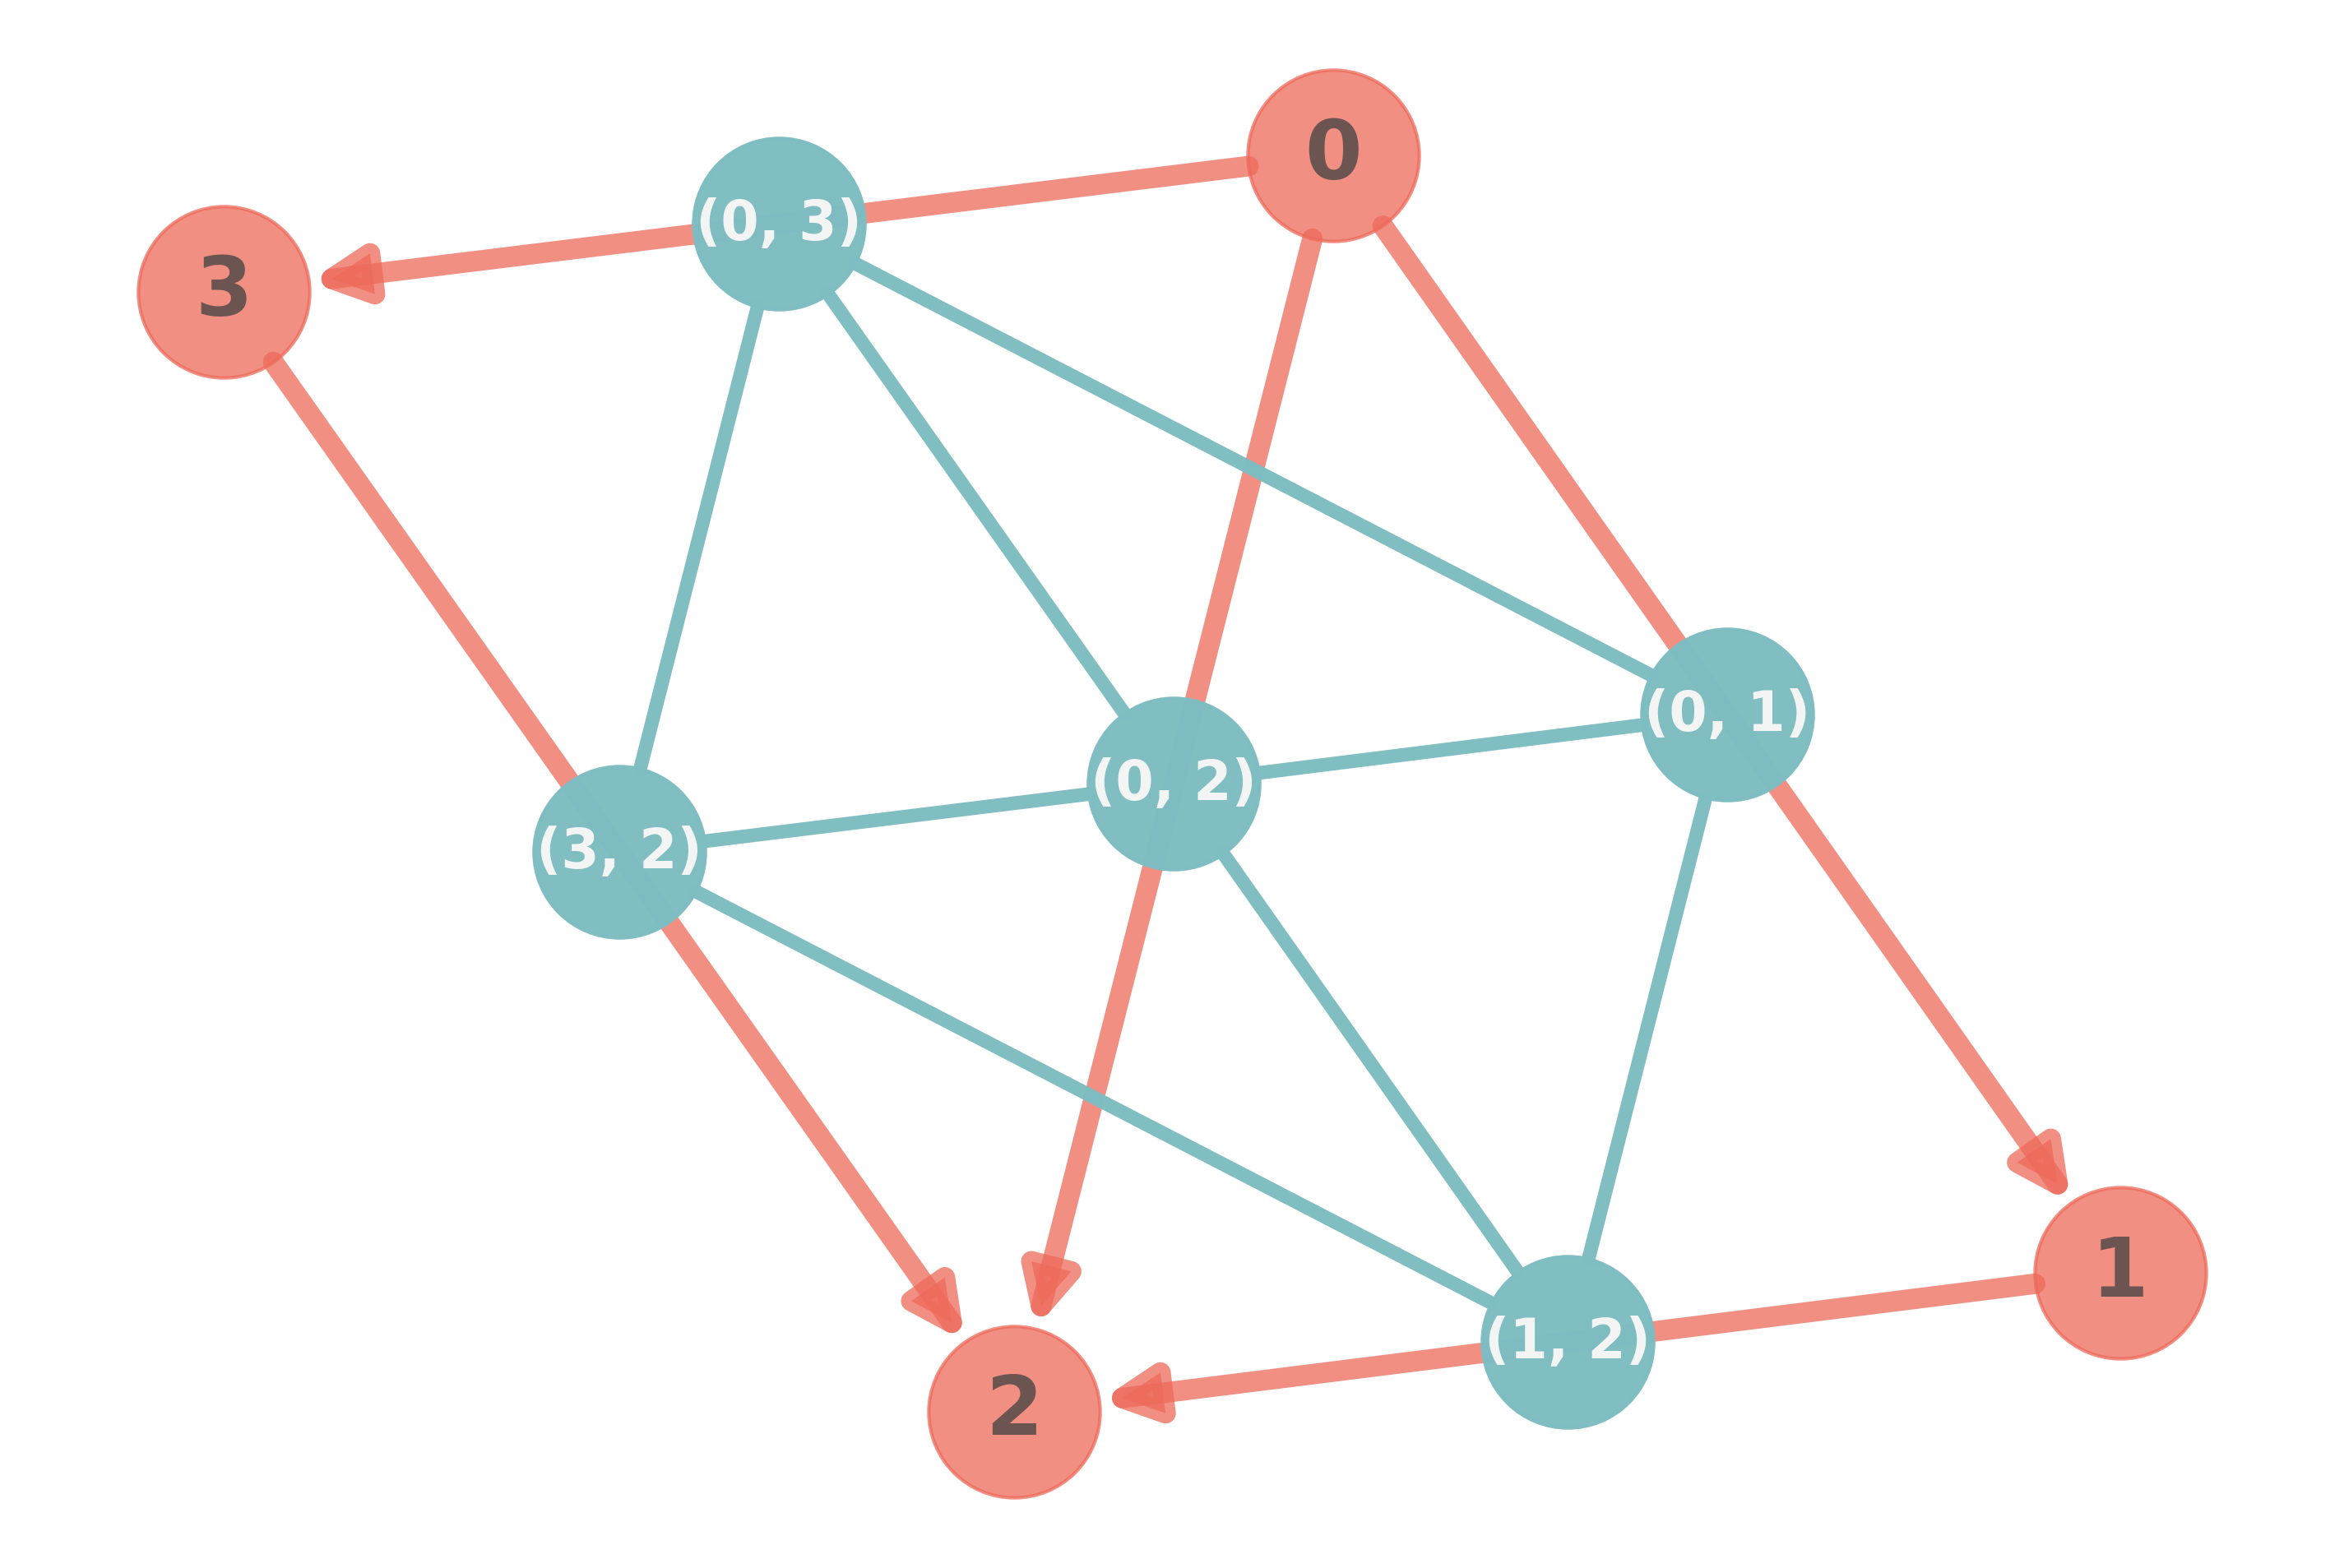

In [2]:
# define the list of directed edges which constitute the graph
edges = [[0, 1], [0, 2], [0, 3], [1, 2], [3, 2]]

# access the GraphHandler class from the graph module in neuralqx
graph = nqx.graph.GraphHandler(edges = edges)

It's that simple! Now, `graph` holds within it all the information needed about the graph. So far, neuraLQX implements the weak coupling limit of Euclidean LQG. In that model, the edges carry charge vectors and the vertices are "trivial". Therefore, we work in a dual representation of the graph, which is shown in green above (the red graph is the one you specified but the green one is the one "operationally" used).

Now that you have defined your graph, you can access several things from this object. For example, you can get the list of minimal loops as follows

In [3]:
graph.get_smallest_loops()

[[0, 1, 2], [0, 2, 3]]

Which tells you the first minimal loop is one which goes from the vertex 0, to the vertex 1, to the vertex 2 and back to 0. You can also look at it in the dual (edge) representation as follows

In [4]:
graph.get_smallest_dual_loops(edge_rep = True)

[[(0, 1), (1, 2), (2, 0)], [(0, 2), (2, 3), (3, 0)]]

You can also compute the signs of the pairs of edges, for example in this case, by using

In [5]:
graph.compute_signs()

and once you have computed them, they are saved in your graph object and you can view them

In [6]:
graph.print_signs()

Vertex: 0
sign((0, 1), (0, 2)) = -1
sign((0, 1), (0, 3)) = -1
sign((0, 2), (0, 3)) = -1
sign((0, 2), (0, 1)) = 1
sign((0, 3), (0, 1)) = 1
sign((0, 3), (0, 2)) = 1

Vertex: 1
sign((1, 0), (1, 2)) = -1
sign((1, 2), (1, 0)) = 1

Vertex: 2
sign((2, 0), (2, 1)) = -1
sign((2, 0), (2, 3)) = 1
sign((2, 1), (2, 3)) = 1
sign((2, 1), (2, 0)) = 1
sign((2, 3), (2, 0)) = -1
sign((2, 3), (2, 1)) = -1

Vertex: 3
sign((3, 0), (3, 2)) = -1
sign((3, 2), (3, 0)) = 1



## 2.0 The Hilbert module

The next natural step after defining a graph is to now define a kinematical Hilbert space on it. The module responsible for this is the `hilbert` module. This module houses within it the `Hilbert` class which can produce for you two types of Hilbert spaces. Let's discuss the first of the two: the full kinematical Hilbert space.

### 2.1 The full kinematical Hilbert space

To define a Hilbert space, you in principle need three things: your graph, a charge cutoff, and the gauge dimensions. Once specified, you can define the full kinematical Hilbert space. This can be very easily done in the following manner.


In [7]:
# first define the gauge dimensions
gauge_dims = 1

# now define the charge cutoff
charge_cutoff = 8

# now define the kinematical Hilbert space by accessing the Hilbert class from the hilbert module in neuralqx
H = nqx.hilbert.Hilbert(graph, cutoff = charge_cutoff, gauge_dimensions = gauge_dims)

Now, you have the full kinematical Hilbert space. The basis states are numpy arrays of quantum numbers, one for each edge in the graph. You can view some information about your space, for example its dimensions, by just printing the variable `H` as follows

In [8]:
print(H)

A Hilbert space with a maximal cut-off of 8 and dimension 1.42 Million (10^6) with 17 local degrees of freedom ([-8 -7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8])^1 at every edge. 


The `Hilbert` class is right now a little awkward... It is an interface which has within it an object, called `hilbert_space` which houses within it the _actual_ Hilbert space. For example, for you to see if the space is finite, you do the following

In [9]:
H.hilbert_space.hilbert_space.is_finite

True

You can also view other properties, such as the number of states in the space, if it is indexable, and more, as follows

In [10]:
# is it computationally indexable?
print(f"Is the space indexable? {H.hilbert_space.hilbert_space.is_indexable}")

# how many states does it have (dimensions)
print(f"How many states does it have? {H.hilbert_space.hilbert_space.n_states}")

# what are the allowed charges for any given edge?
print(f"Allowed charges per edge: {H.hilbert_space.hilbert_space.local_states}")

Is the space indexable? True
How many states does it have? 1419857
Allowed charges per edge: [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


You also have access to some nice functions. For example, if the space is finite and indexable, then you can convert between the sequential labeling of the space and the actual basis state as follows

In [11]:
# get the basis state which is labeled by 0 in the current sequential labeling of states
H.hilbert_space.hilbert_space.numbers_to_states(0)

Array([-8, -8, -8, -8, -8], dtype=int64)

In [12]:
# get the number of the state [-1, 0, 1, 2, -3] according to this sequential labeling
# the states have to be numpy arrays, so import numpy
import numpy as np

H.hilbert_space.hilbert_space.states_to_numbers(np.array([-1, 0, 1, 2, -3]))

Array(626727, dtype=int32)

### 2.2 The gauge invariant subspace

Often times, we deal with complicated graphs, or we want to consider relatively high charge cutoffs. In that case, the dimensions of the Hilbert space grow _rapidly_. To combat this, we have a gauge invariant subspace implementation which, instead of providing you all the states in the entire kinematical Hilbert space, it only contains ones which satisfy a certain gauge fixing.

Let us talk a little bit of the advantages of this, and then look into how to build a gauge invariant subspace. Now, let us take a moment to analyse this graph above. As it stands the kinematical Hilbert space is of dimensions (if we let our gauge dimensions be 3 instead of 1)
$$
\dim \mathcal{H} = (2 m_{max} + 1)^{3 \mid E(\gamma)\mid}
$$
where $\mid E(\gamma)\mid = 5$.

We now need to derive a gauge fixing. Since the Gauß constraint ensures charge conservation at every vertex, this can be done by looking at which edges are free to have any value for their charge, and which edges get their charges fixed by other edges. Let us denote by $E_F(\gamma)$ the set of 'free' edges (that is, ones which are not fixed by other edges). For example, at the vertex labeled by 1, the edge [0, 1] fixes the edge [1, 2]. Similarly, the edge [0, 3] and [3, 2] fix each other at the vertex labeled by 3. Doing this for the remaining edges, we see that $\mid E_F(\gamma)\mid = 2$.

Comparing this with the dimensions of the full Hilbert space, we see that the reduction ratio $R$ is
$$
R = \frac{\ln\dim \mathcal{H}^G}{\ln\dim \mathcal{H}} = \frac{\mid E_F(\gamma) \mid}{\mid E(\gamma) \mid}
$$

From which we can read that
$$
\dim \mathcal{H}^G = (\dim \mathcal{H})^R
$$

For our specific case, we see that $R = 0.4$. More explicitly, if we consider the relatively small cutoff $m_{max} = 2$, then $\dim\mathcal{H} = 30.52 \times 10^{9}$ while $\dim\mathcal{H}^G = 15.62 \times 10^{3}$, constituting only $5.12 \times 10^{-5} \%$ of the total Hilbert space!

This reduction of the number of states come with several advantages due to the lower computational cost:
- The graphs considered can be relatively large
- The ability of the network to converge increases
- The convergence statistics become well-behaved
- The simulations are drastically quicker

In the current graph orientation we see that:
- the edge [0, 1] fixes the edge [1, 2]
- the edge [0, 3] fixes the edge [3, 2]
- the edges [0, 1] and [0, 3] fix the edge [0, 2]

For last gauge fixing condition, the charges should sum up as $m_1 = -m_0 \oplus -m_2$, where $\oplus$ is the modded addition described in section 1.1 of [this paper](https://arxiv.org/pdf/2402.10622).

Now, let us see how to write a gauge fixing in the language of neuraLQX. The incoming edges should always be composed of one edge, therefore you may need to rewrite some gauge conditions. This is not the case here. Therefore, the first gauge condition would be `[['(0, 1)'], ['(1, 2)']]`. The second gauge condition would be `[['(0, 3)'], ['(3, 2)']]`. Lastly, the last condition is a little tricky due to the charges on the right hand side of the gauge condition having a negative sign. We have introduced the following notation:

- For a gauge condition $m_{e_1} = -m_{e_2} \oplus -m_{e_3} \oplus \cdots \oplus -m_{e_k}$, then use `[['e_1'], ['N', 'e_2, 'e_3', ..., 'e_k']]`. Here, the `'N'` is used to prescribe the modded addition of charges with every charge having a minus sign.
-  For a gauge condition $m_{e_1} = m_{e_2} \oplus -m_{e_3} \oplus m_{e_4} \oplus \cdots \oplus -m_{e_k}$, then use `[['e_1'], ['e_2, '-e_3', 'e_4', ..., '-e_k']]`. Here, specifying a minus sign for one edge will only insert the charge of that edge with a negative value in the modded sum.

Given this, the last gauge condition for our graph can be written as `[['(0, 2)'], ['N', '(0, 1)', '(0, 3)']]`. All together, the gauge fixing array takes the following form:

In [13]:
gauge_fixing = [
    [['(0, 1)'], ['(1, 2)']],
    [['(0, 3)'], ['(3, 2)']],
    [['(0, 2)'], ["N", '(0, 1)', '(0, 3)']]
]

And now that we have our gauge fixing, we can proceed with defining our Hilbert spaces as usual, except now we tell it that it must contain only gauge invariant state

In [14]:
# define your gauge dimensions
gauge_dims = 3

# your charge cutoff
charge_cutoff = 2

H = nqx.hilbert.Hilbert(graph, charge_cutoff, is_gauge_invariant = True, gauge_fixing = gauge_fixing, gauge_dimensions = gauge_dims)

And now if we print it, we see that it is gauge invariant!

In [15]:
print(H)

A gauge invariant Hilbert space with a maximal cut-off of 2 and dimension 15.62 Thousand (10^3) with 15 local degrees of freedom ([-2 -1  0  1  2])^3 at every edge. The gauge fixing is: [[['(0, 1)'], ['(1, 2)']], [['(0, 3)'], ['(3, 2)']], [['(0, 2)'], ['N', '(0, 1)', '(0, 3)']]].


This space has 15.62 thousand gauge invariant states. To put this in perspective, the full kinematical space would have 30.5 BILLION states. We have just filtered out 30.5 billion states and selected from them 15.62 thousand states which satisfy the gauge fixing, in less than one second. This is possible because neuraLQX, as well as its primary dependencies like NetKet, utilise jut-in-time compilation which allows for fast computations.

Another thing that you can do with your `Hilbert` object is to draw random states from the space. To do this, you have to specify a JAX PRNG Key and tell it how many random states do you have. If you are in the gauge invariant subspace, it will only produce gauge invariant states. This can be done as follows

In [16]:
import jax

# generate 1 random state from our gauge invariant subspace
H.random_state(jax.random.PRNGKey(0), size = 1)

Array([-1., -1.,  2., -1.,  2.,  2.,  1.,  2.,  2.,  2.,  1.,  2.,  2.,
        1.,  2.], dtype=float32)

Note that we have now a Hilbert space with gauge dimensions = 3. This means we have a $U(1)^3$ kind of gauge. In our implementation, we cannot have vectors as degrees of freedom on the edges. This is why the state printed above is not composed of vectors as the degrees of freedom on every edge. Rather, we have 3 copies of a $U(1)$ theory, and the state is to be understood as the degrees of freedom of every copy placed one after the other.

For example, in our graph, we have 5 edges. This means the first five numbers in the array above, so `[-1, -1, 2, -1, 2]` are the 0-th components of the charge vectors living on the edges. The second five numbers `[2, 1, 2, 2, 2]` denote the 1-st components and the last five `[1, 2, 2, 1, 2]` denote the 2-nd components. Therefore, the first edge has the charge vector composed of `(-1, 2, 1)`, which are the first entries in the three little arrays outlined above.

## 3.0 The gauge_groups module

Next up on our itinerary is the `gauge_groups` module. Currently, neuraLQX supports only the $U(1)^N$ gauge group used in the weak coupling limit. However, as further groups are implemented, they will be placed in this module. The `gauge_groups` module currently has within it the `U1Gauge` interface which will be responsible for creating the appropriate $U(1)^N$ group for you. In reality, what it creates is the gauge constraint with appropriate gauge dimensions. To create a $U(1)^N$, group, you just do the following

In [17]:
# create a gauge_dims = 3 dimensional U(1) group
# we do this by accessing the U1Gauge from the gauge_groups module
# Note: the dimensions of the gauge group should match the gauge dimensions of your Hilbert space!
gauge_group = nqx.gauge_groups.U1Gauge(H, gauge_dimensions = gauge_dims)

And you can as always see some information about it by printing it

In [18]:
print(gauge_group)

A gauge group of type: U(1)^3


Accessing the Gauß constraint is as easy as shown here

In [19]:
gauge_group.gauge_constraint()

LocalOperator(dim=15, #acting_on=39 locations, constant=0.0, dtype=float64)

And that's it! Now, we want to bring it full circle by looking at not only the Gauß constraint, but whatever gravity constraint there is depending on your system

## 4.0 The lqx module

The `lqx` module is the last piece of building your LQG model. It will contain within it the entire LQG model, including your graph, Hilbert space, gauge group and your gravity constraints. Currently, the module only has the implementation of the weak coupling limit of Euclidean LQG. You create a WCL model by using the `EuclideanWCL` interface which sits in the `WCL` submodule which sits in the `lqx` module.

When creating a model, you have the ability to specify a few things. For example, you need to specify what are the spacetime dimensions ("3" for a 2+1 model or "4" for a 3+1 model). You also give it the Hilbert space and the gauge group you created. This is done as follows

In [20]:
# access the EuclideanWCL interface through the lqx module of neuralqx
lqx = nqx.lqx.EuclideanWCL(H, gauge_group, spacetime_dims = 3)

The line above just created a 3-dimensional model of LQG in the WCL. In this case, the default constraint of the theory is the BF-theory type constraint. Namely, it is $\hat{C} = \hat{F} + \hat{G}$ where the curvature constraint takes the form

$$
\hat{F} = \sum_{\alpha \in L(\gamma)} (\hat{h}_{\alpha} - \mathbb{I})(\hat{h}^{\dagger}_{\alpha} - \mathbb{I}),
$$

and the Gauß constraint takes the form

$$
\hat{G} = \sum_{v \in V(\gamma)}\left(\sum_{e \in E_{in}(v)}\hat{N}_{e} - \sum_{e' \in E_{out}(v)}\hat{N}_{e'} \right)
$$

However, since our Hilbert space that we last created and fed to the EuclideanWCL object is gauge invariant, the constraint is currently only the curvature constraint. The module automatically detects this and provides the full constraint of the theory $\hat{C}$ based on your Hilbert space. To access the full constraint, you just do the following

In [21]:
lqx.constraint

LocalOperator(dim=15, #acting_on=6 locations, constant=12.0, dtype=float64)

The `constraint` attribute in your EuclideanWCL instance will always house your full constraint. However, there might be other constraints of interest. For example, in 3d Euclidean gravity, you also have the Thiemann regularised constraint. This can be accessed via the following

In [ ]:
lqx.model.thiemann_regularized_constraint()

Depending on your model, you also have other operators. For example, in 3d gravity, we already have the spatial volume oeprator which we can access as follows

In [22]:
# this now gives you the volume operator acting on the vertex 0 in the red graph
lqx.model.volume_operator_at_vertex(0)

LocalOperator(dim=15, #acting_on=63 locations, constant=0.0, dtype=float64)

Note that depending on your spacetime dimensions that you have chosen when creating the `EuclideanWCL`object, these operators will change! You can call the same functions but they will provide different operators based on your spacetime dimensions. In short, you can always find your correct volume operator, irrespective of which spacetime dimensions you chose using the above function.

The case for 4d gravity is a little different. There, the Thiemann regularised constraint can be accessed as shown above as well. However, this will return for you, as expected,

$$
\hat{H}^E = \sum_{v \in V(\gamma)} \hat{H}_v
$$

where $\hat{H}^E$ is the Euclidean Thiemann regularised constraint and $\hat{H}_v$ is the constraint acting on a vertex. If you want to construct the Master constraint in this theory, it goes a little differently, and this will be discussed in depth in Tutorial 4 where we look at 4d gravity. However, it is as simple as calling the following line


In [ ]:
# Note that in 3d gravity, this has no functionality
lqx.model.master_constraint

You can also access the vertex Hamiltonian $\hat{H}_v$ by using

In [ ]:
# this gives the vertex Hamiltonian acting on the vertex 0 in your red graph
# Note that in 3d gravity, this has no functionality
lqx.model.vertex_TRC(0)

The implementation is very flexible. For example, suppose you have now created some operator, call it `my_operator` which you would like to add to the constraint so that you also minimise that. For you to modify the constraint, you just have to do the following

In [ ]:
lqx.constraint += my_operator

We will talk in depth about creating custom operators in another tutorial, but for now let us proceed.

## 5.0 The solver module

Now you have essentially an entire LQG model sitting in your laptop. How do we go about solving that? Well, two ways. If your system is small enough (or you have so much TBs of RAM...), you can exactly diagonalise the constraint using

In [23]:
lqx.exact_diagonalization()

# you can also specify by hand a supposed value, if exact diagonalisation is not possible but you happen to know the minimum eigenspace
# you can do this by specifying that explitictly in the function
# lqx.exact_diagonalization(true_value = 0.0)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    min<C> using Lanczos exact diagonalisation: 3.884316745963663e-15                                 │
│   Timestamp:  2025-01-25 20:47:34                                                                               │
│                                                                                                                 │
╰──────────────────────────────── Logged by EuclideanWCL.exact_diagonalization() ─────────────────────────────────╯

However, this is not really possible for even the samllest systems of interest in 3d or 4d gravity. neuraLQX using the Neural Quantum State (NQS) ansatz to attempt to solve these constraints, and the `solver` module is the one responsible for doing that for you.

### 5.1 Creating a solver

The `solver` module houses within it the `Solver` interface, which is the one responsible for solving your model using the NQS ansatz. When creating a solver, you have to give it your lqx object.

Further, there are two other optional parameters. By default, the solver will create a folder called "Output Data" which sits in the same directory where the script you ran is and will save your results there. For each simulation, a unique hash is created, and the entire simulation results are saved in a folder whose name is that unique hash and this folder will sit inside the "Output Data" folder. Therefore, your "Output Data" will have results of different simulations, each saved in a folder, and each folder is named with a unique hash.

First, let us look at the simplest way of creating a solver. This can be done as follows

In [24]:
# access the Solver class from the solver module
solver = nqx.solver.Solver(lqx)

Now, let us look how to go about changing the name of the main Output Data folder. This can be done as follows

In [ ]:
solver = nqx.solver.Solver(lqx, output_data_path = "Your Folder Name")

It may be the case that you are planning to run 100 simulations for a specific cutoff. Instead of the entire output folder being populated with folders whose names are just unique hashes, you can organise this a bit. You can create a subfolder in your main output folder and give it whatever name you want. If you use the same subfolder name in these 100 simulations, then they will all be saved and you then know what simulations were there. This can be done as follows

In [ ]:
solver = nqx.solver.Solver(lqx, output_data_path = "Output Data", hpc_path_seed = "Cutoff 1")

The above will result in your simulation results being saved in the path `Output Data/Cutoff 1/`, which may help you organise your data a little bit.

### 5.2 Setting the sampler

The expectation values in neuraLQX are computed using Monte-Carlo methods. Spefically, for some operator $\hat{C}$, the expectation value is defined as

$$
\langle \hat{C} \rangle = \sum_{i}^{N_{MC}} \frac{C_{loc}(\underline{m}_i)}{N_{MC}},
$$

where $N_{MC}$ is the number of samples in the Monte-Carlo process and $C_{loc}(\underline{m}_i)$ is the *local energy* (local estimator if $\hat{C}$ is not the "Hamiltonian"). The local energy can be written as

$$
C_{loc}(\underline{m}) = \sum_{\underline{\tilde{m}}} \langle \underline{m} \mid \hat{C} \mid \underline{\tilde{m}} \rangle \frac{\psi(\underline{\tilde{m}})}{\psi(\underline{m})}.
$$

This however has an exponential amount of terms, so it can be reduced by looking only at the *connected components* in the sum (e.g. states $\underline{\tilde{m}}$ which give non-zero matrix elements with $\underline{m}$. Thus,

$$
C_{loc}(\underline{m}_i) = \sum_{\underline{\tilde{m}} \text{ s.t. } \langle \underline{m} \mid \hat{C} \mid \underline{\tilde{m}} \rangle \neq 0} \langle \underline{m} \mid \hat{C} \mid \underline{\tilde{m}} \rangle \frac{\psi(\underline{\tilde{m}})}{\psi(\underline{m})} = \sum_{\underline{\tilde{m}} \text{ s.t. } \langle \underline{m} \mid \hat{C} \mid \underline{\tilde{m}} \rangle \neq 0} \langle \underline{m} \mid \hat{C} \mid \underline{\tilde{m}} \rangle \exp(\log\psi(\underline{\tilde{m}}) - \log\psi(\underline{m}))
$$

In practice, we sample the space using some sort of sampler and pick a total of $N_{MC}$ samples to compute the expectation value of. This is done by choosing $K$ number of chains, each with $M$ samples, such that $KM = N_{MC}$. If the sample is small enough, these samples are generated using exact inference methods. If not, then we have to use some sort of Metropolis-Hastings type sampler.

#### 5.2.1 Exact samplers

In the `Solver`, you can choose which sampler to use, for example an Exact Sampler, by doing the following.

In [25]:
# This utilise in the solver the Exact Sampler, which samples using exact inference methods
solver.set_sampler(sampler_type = "Exact Sampler")

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Sampler `Exact Sampler` initialized.                                                              │
│   Timestamp:  2025-01-25 20:47:43                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_sampler() ─────────────────────────────────────────╯

#### 5.2.2 Metropolis-Hastings samplers

You can also choose a Metropolis type sampler. These are categorised based on their transition rules. For example, a "Metropolis Local" sampler will propose a new state from the given state by randomly changing one of the quantum numbers of the given state to a random allowed quantum number. A "Metropolis TwoLocal" would act in the same way, except changing the quantum numbers of two randomly chosen edges. A "Metropolis Exchange" would exchange the quantum numbers of two randomly chosen edges which are seperated by some distance.

In all of these samplers, you have the ability to define the number of chains, the number of samples per chain, whether to reset the chains every iteration and how many times to sweep through the chain. The following is how you would define a Metropolis sampler with a local transition rule.

In [26]:
solver.set_sampler(
    sampler_type = "Metropolis Local",
    number_of_chains = 50,
    number_of_samples = 250,
    number_of_sweeps = 10,
    reset_chains = False,
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Sampler `Metropolis Local` initialized.                                                           │
│   Timestamp:  2025-01-25 20:47:46                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_sampler() ─────────────────────────────────────────╯

The above line will now set a Metropolis type sampler with a local transition rule, which has 50 chains each with 250 samples (so 12500 total samples) and will go through each chain 10 times. It will also not reset the chain at every Monte-Carlo step, but rather carries from the previously computed chain.

#### 5.2.3 Gauge invariant sampling

All of these transition kernels defined above have something in common: they do *not* preserve the gauge invariance of the given state! Therefore, if you are working in the gauge invariant subspace, these will propose states which are *not* gauge invariant, which means you are now computing the expectation value of your constraint using non gauge invariant states, effectively arriving at a solution which is not gauge invariant!

To deal with this, we have created two transition kernels which respect the gauge fixing you have specified. The first is the `RandomU1GaugeSampler` which proposes for any given state a random gauge invariant state. Since everything is in the WCL, therefore the "U1" in the name. Of course, this is not a clever sampler and can lead you to convergence issues.

Another, more clever, transition kernel is the `U1GaugeSampler`. This kernel will do the following:
- For a given basis state $\sigma := |\vec{m}_1\rangle \otimes |\vec{m}_2\rangle \otimes \cdots \otimes |\vec{m}_N\rangle$, determine the set of free and slave edges. Here, the free edges are ones which are not being fixed by your gauge fixing, but ones which fix others. The rest of the edge which are being fixed by the free edges are called slave edges.
- Randomly pick one (or more, up to you) edge(s) from the set of free edges
- Change its quantum number by either (i) proposing a random allowed quantum number, or (ii) randomly incrementing/decrementing its quantum number by 1. This is up to you to decide.
- Given the new set of free edges, reimpose the gauge fixing in topological order on the slave edges and propose the new state

This sampler allows you to take refined and local steps in your gauge invariant subspace, depending on the choices you made during constructing it. In the following, we construct a Metropolis sampler which has the `U1GaugeSampler` transition kernel.

In [27]:
solver.set_sampler(
    sampler_type = "U1 Gauge Sampler",
    number_of_chains = 50,
    number_of_samples = 250,
    number_of_sweeps = 10,
    reset_chains = False,
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Sampler `U1 Gauge Sampler` initialized.                                                           │
│   Timestamp:  2025-01-25 20:47:51                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_sampler() ─────────────────────────────────────────╯

The above command will create a Metropolis sampler with a U(1) gauge invariant local transition kernel which increments or decrements the quantum number of the chosen edge to changed by 1. Similarly, to use the `RandomU1GaugeSampler` kernel, you just do the following:

In [28]:
solver.set_sampler(
    sampler_type = "Random U1 Gauge Sampler",
    number_of_chains = 50,
    number_of_samples = 250,
    number_of_sweeps = 10,
    reset_chains = False,
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Sampler `Random U1 Gauge Sampler` initialized.                                                    │
│   Timestamp:  2025-01-25 20:47:52                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_sampler() ─────────────────────────────────────────╯

You also have the ability to use multiple samplers at a time. This can be done by a special type of sampler called a "Weighted Sampler". The weighted sampler is of Metropolis type, so you just have to specify for it the type of transition kernels. For example, the following will instruct the solver to use the weighted sampler with both the `U1GaugeSampler` and the `RandomU1GaugeSampler` transition kernels, with different probabilities for each transition kernel

In [29]:
from neuralqx.samplers import U1GaugeSampler, RandomU1GaugeSampler

solver.set_sampler(
    sampler_type = "Weighted Sampler",
    rules = [U1GaugeSampler(), RandomU1GaugeSampler()],
    probabilities = [0.9, 0.1],
    number_of_chains = 50,
    number_of_samples = 250,
    number_of_sweeps = 10,
    reset_chains = False,
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Sampler `Weighted Sampler` initialized.                                                           │
│   Timestamp:  2025-01-25 20:47:54                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_sampler() ─────────────────────────────────────────╯

Now, the solver will use a Metropolis type sampler with the transition kernel being the `U1GaugeSampler` kernel 90% of the time and the other 10% it will use the `RandomU1GaugeSampler` kernel. You can specify an arbitrary number of transition kernels for this weighted sampler.

### 5.3 Choosing an optimiser

In the optimisation process, we attempt to minimise the expectation value of some constraint. This is done by using some minimisation method, such as stochastic gradient descent. In neuraLQX, you have the option to choose different optimisers. Currently, we use [optax](https://optax.readthedocs.io/en/latest/index.html) based optimisers and we support the following:
- Stochastic gradient descent (SGD)
- Adaptive momentum (Adam)
- Momentum based SGD
- RMSProp
- AdaGrad
- Adabelief
- Yogi
- AmsGrad

You can refer to the optax documentation [here](https://optax.readthedocs.io/en/latest/api/optimizers.html) for a description of each optimiser. Defining an optimiser is easy, you just choose one and choose its parameters. Currently, every optimiser is configured with a default set of parameters which correspond to the ones in the optax API [reference](https://optax.readthedocs.io/en/latest/api/optimizers.html). Therefore, you really only need to choose a learning rate!

In [30]:
solver.set_optimizer(
    optimizer_name = "Adam",
    learning_rate = 0.001,
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Optimizer `Adam` initialized.                                                                     │
│   Timestamp:  2025-01-25 20:47:59                                                                               │
│                                                                                                                 │
╰─────────────────────────────────────── Logged by Solver.set_optimizer() ────────────────────────────────────────╯

Now, we have instructed our solver to use the Adam optimiser with a fixed learning rate of 0.001.

#### 5.3.1 Scheduled learning rate

Sometimes, a fixed learning rate just doesnt cut it. It may work well only for a portion of the simulation. For example, a large learning rate can help you descent quickly at the start of the minimisation to you minima, but then once there, you cannot stay there simply because your weights and biases are being updated by a large amount. On the other hand, a small learning rate might take you forever to find your minima, but once there you stay there.

Schedulers allow you to have a learning rate that is *not* fixed. It starts at some initial value and then decays over time according to some decay rate. neuraLQX currently supports some optax based schedulers. Specifically, we support:
- exponential decay
- linear decay
- cosine decay

The optax documentation [here](https://optax.readthedocs.io/en/latest/api/optimizer_schedules.html) provides all the information about them. To instruct the solver to use a schedule, instead of specifying a fixed learning rate, just tell it which one to use and provide the parameters of the scheduler (they can be found in the optax documentation [here](https://optax.readthedocs.io/en/latest/api/optimizer_schedules.html)). the following is an example of a linear decay schedule.

In [31]:
solver.set_optimizer(
    optimizer_name = "Adam",
    scheduler_type = "linear decay",
    scheduler_kwargs = {
        "init_value": 0.1,
        "end_value": 0.0001,
        "transition_steps": 1000,
    }
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Optimizer `Adam` initialized.                                                                     │
│   Timestamp:  2025-01-25 20:48:03                                                                               │
│                                                                                                                 │
╰─────────────────────────────────────── Logged by Solver.set_optimizer() ────────────────────────────────────────╯

The above code will now also use the Adam optimiser. However, instead of a fixed learning rate, it will start with a learning rate of 0.1, which will linearly decay to a rate of 0.0001 over 1000 steps which by default start from the begining of the simulation.

The use of schedules (with appropriate initialisation) have proven to provide better and faster convergence with fewer number of network parameters when compared to a fixed learning rate.

### 5.4 Choosing a network

The last piece of the puzzle is defining some network architecture to be used in the process. Currently, there are two options. Either implement your own network architecture, or use one which is already implemented by either neuraLQX or NetKet. The neuraLQX networks can be found in the `nn` module. The NetKet architectures are found in the `models` module.

#### 5.4.1 Using NetKet networks

Using NetKet based networks is very simple, you just have to choose and initialise one of their networks as follows.

In [32]:
# import the Restricted Boltzmann Machine based network
from netket.models import RBM

# create it
model = RBM()

# tell the solver to use it
solver.set_network(model)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Network `RBM` initialized.                                                                        │
│   Timestamp:  2025-01-25 20:48:06                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_network() ─────────────────────────────────────────╯

#### 5.4.2 Using neuraLQX networks

Just as easily, you can use neuraLQX networks by initialising one of them as follows

In [33]:
# import the RevNet network
from neuralqx.nn import RevNet

# initialise it (this is different based on your chosen model)
model = RevNet(
    lqx=lqx,
    number_of_cnn_features=60,
    rng_key=jax.random.PRNGKey(0),
)

# instruct the solver to use it
solver.set_network(model)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Network `RevNet` initialized.                                                                     │
│   Timestamp:  2025-01-25 20:48:19                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_network() ─────────────────────────────────────────╯

#### 5.4.3 Creating your own architecture

You can also create your own custom architecture, you just have to follow some rules:
- First, the network should be based on [Flax Linen](https://flax-linen.readthedocs.io/en/latest/) because they are compatible with the underlying infrastructure of neuraLQX and NetKet.
- Second, the network should inherit from `flax.linen.Module` and therefore cannot have an `__init__` function and any class attributes must be hashable objects (e.g. strings, numbers, other classes but not numpy or JAX arrays).
- Third, your model will be just-in-time compiled with JAX. Therefore, do not use any numpy functions (unless you really know what you are doing). Rather, always use jax.numpy versions of them (e.g. `jax.numpy.sin()` instead of `numpy.sin()`).
- Fourth, whatever your network is, it has to have a method `__call__`. This method should be wrapped by a `flax.linen.compact` decorator. Whatever is inside this function is basically your network architecture. This is what will be evaluated/used when the network is called upon to compute an amplitude.
- Fifth, your `__call__` method should be able to accept inputs of the shape (B, N) where B is a batch size and N is the number of edges in your space (in simple words, it should be able to accept batches of states).

The following is an example to recreate the RBM architecture from scratch and instruct the solver to use it

In [34]:
# import flax.linen
import flax.linen as nn

# import jax.numpy
import jax.numpy as jnp

# create a new class which inherits from flax.linen.Module
class RBMFromScratch(nn.Module):

        # we define some attributes, for example the y is some constant
        y : float = 1.0

        # and alpha is some enlargement factor to decide how many hidden nodes do we have
        alpha : int = 1

        # create the __call__ method, notice how it is decorated by the flax.linen.compact decorator
        # the input x here is assumed to be a jax array of shape (B, N), where N is the size of the system
        @nn.compact
        def __call__(self, x):
                # the following line will create a dense layer with alpha * N features
                dense = nn.Dense(features = self.alpha * x.shape[-1])

                # apply the dense layer to your input
                x = dense(x)

                # sum the output and multiply by the constant y
                return self.y * jnp.sum(x, axis = -1)

# now create an object of this architecture
model = RBMFromScratch()

# tell the solver to use it
solver.set_network(model)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Network `RBMFromScratch` initialized.                                                             │
│   Timestamp:  2025-01-25 20:48:43                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_network() ─────────────────────────────────────────╯

### 5.5 Callbacks

Now, our solver has all the tools necessary to start the simulation. However, before we do that, let's discuss callbacks. Callbacks are functions which you can tell the solver to execute after every single iteration in the minimisation process. For example, neuraLQX has a callback called `StateExportCallback` which you can give it a desired target for your cost function and whenever the cost function's value is equal to, or dips below, that desired value, the entire variational state as well as the sampler will be exported to the output folder of the current simulation. This for example helps you pick look at certain states achieved during the simulation without having to stop it and to be able to start the simulation from a certain stage later on.

The neuraLQX callbacks can be found in the `callbacks` module and creating one is as easy as follows

In [ ]:
# import the callback
from neuralqx.callbacks import StateExportCallback

# create it, and for now keep it aside. We will give it to the solver later
state_export_callback = StateExportCallback(solver = solver, target = 0.000001)

Other callbacks, such as one which logs the acceptance rate of Metropolis type samplers, can be found in the `callbacks` module and initialised individually. You can supply a list of callbacks to the solver, so you dont have to choose just one.

### 5.6 Running the solver

To start the simulation, you use the `.run()` command. You will need to at least specify the number of iterations to carry out. So this is as simple as the following

  0%|          | 0/1000 [00:00<?, ?it/s]

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    State serialised to disc.                                                                         │
│   Timestamp:  2025-01-25 20:49:19                                                                               │
│                                                                                                                 │
╰────────────────────────────────── Logged by Solver.export_serialized_state() ───────────────────────────────────╯

╭───────────────────── neuraLQX Output Log 20:49:19 - 25.01.2025 (S:6292fb-95a02cb3e5) 1.0.0 ─────────────────────╮
│                                                                                                                 │
│   Optimization Results:   ╭─────────────────────────────────────────────────────────────────────────────────╮   │
│                           │                                                                                 │   │
│                           │   Exact diagonalization result:            3.884316745963663e-15                │   │
│                           │   Network result:                          8.242 ± 0.050 [σ²=0.227, R̂=1.2696]   │   │
│                           │   Accuracy:                                -2.121763742290956e+17               │   │
│                           │   Average min<C> over last 100             8.253(0.005)                         │   │
│                           │   iterations (stddev):                                                          │   │
│                           │   Average R_Hat over last 100 iterations   1.277(0.002)                         │   │
│                           │   (stddev):                                                                     │   │
│                           │                                                                                 │   │
│                           ╰─────────────────────────────────────────────────────────────────────────────────╯   │
│   Network Configs:        ╭─────────────────────────────────────────────────────────────────────────────────╮   │
│                           │                                                                                 │   │
│                           │   Network type:                     RBMFromScratch                              │   │
│                           │   Number of network parameters:     240                                         │   │
│                           │   param_dtype:                      float64                                     │   │
│                           │   activation:                       log_cosh                                    │   │
│                           │   alpha:                            1                                           │   │
│                           │   use_hidden_bias:                  True                                        │   │
│                           │   use_visible_bias:                 True                                        │   │
│                           │   precision:                        None                                        │   │
│                           │   kernel_init:                      init                                        │   │
│                           │   hidden_bias_init:                 init                                        │   │
│                           │   visible_bias_init:                init                                        │   │
│                           │   number_of_cnn_features:           60                                          │   │
│                           │   lqx:                              'EuclideanWCL'                              │   │
│                           │   rng_key:                          [0 0]                                       │   │
│                           │   is_auto_reg:                      False                                       │   │
│                           │   dropout_rate:                     0.2                                         │   │
│                           │   y:                                1.0                                         │   │
│                           │   Params(network) / dim(Hilbert):   1.536 %                                     │   │
│                           │                                                                                 │   │
│                           ╰──────────────────────────

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    NEURALQX LOGGER: Data exported to disc.                                                           │
│   Timestamp:  2025-01-25 20:49:19                                                                               │
│                                                                                                                 │
╰───────────────────────────────────── Logged by Logger.write_log_to_file() ──────────────────────────────────────╯

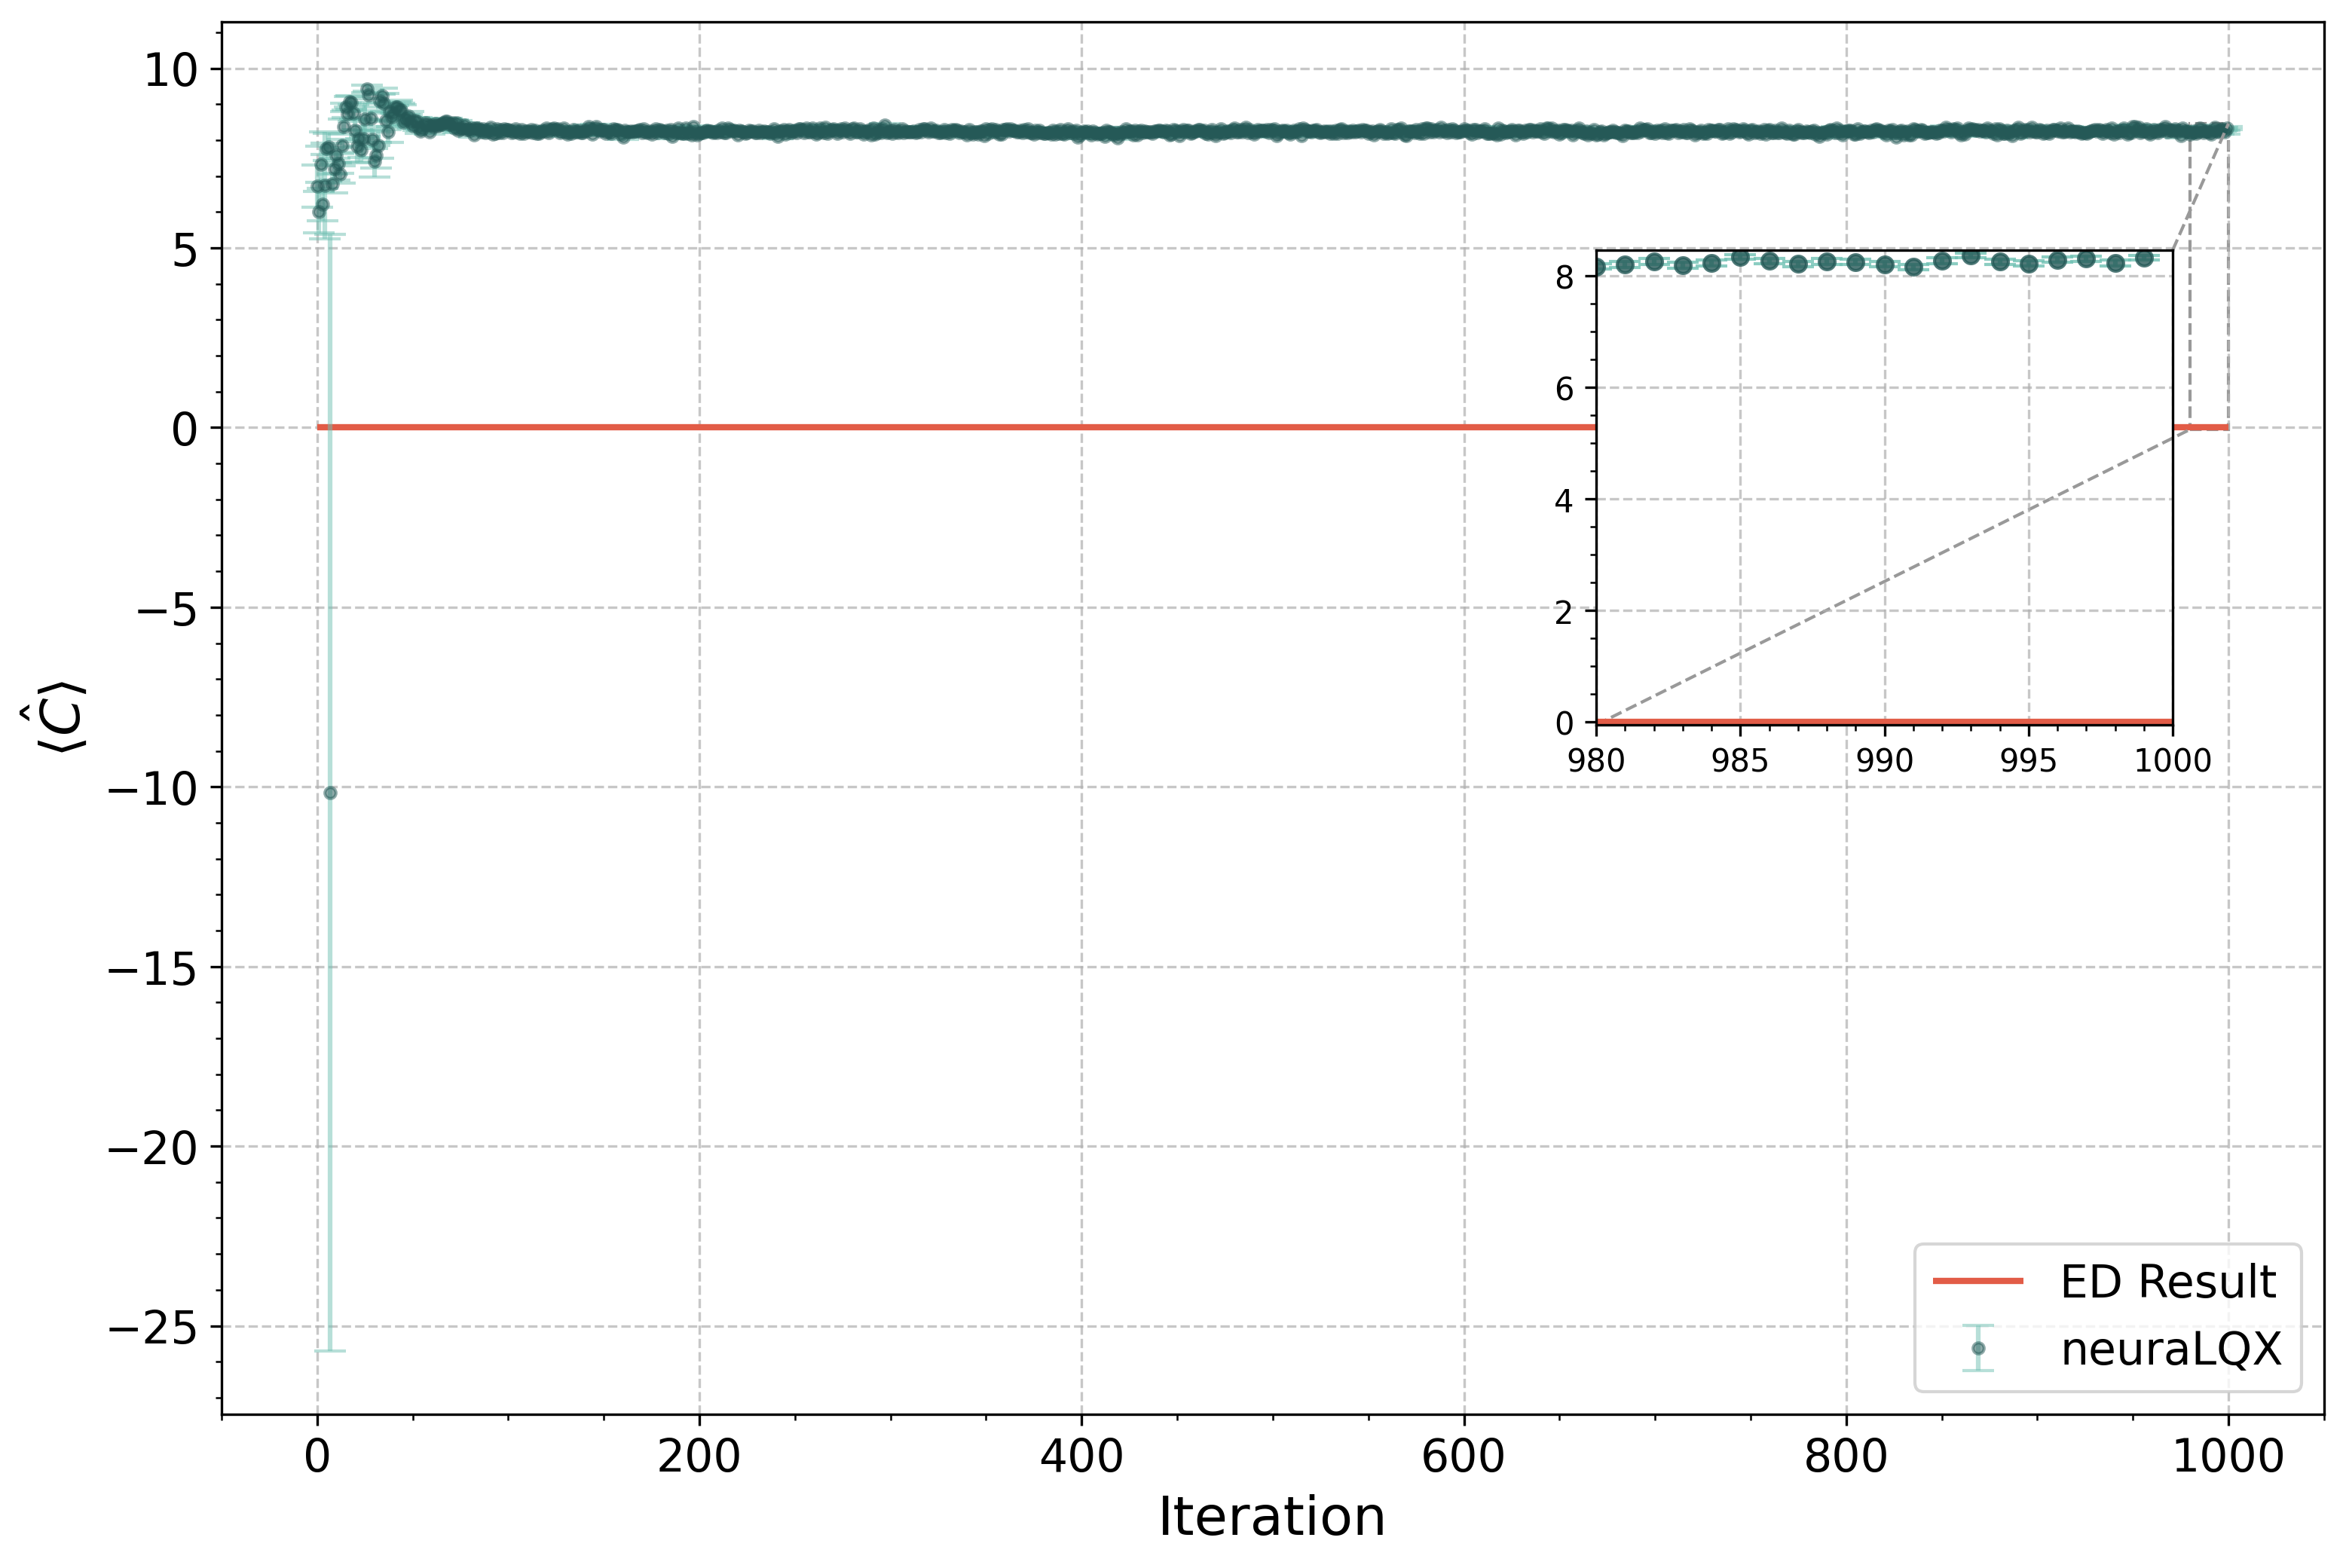

In [35]:
solver.run(number_of_iterations = 1000)

Where we can see that the RBM architecture is not very good at solving the curvature constraint for 3d Euclidean LQG in the WCL...

#### 5.6.1 Turning off printing and plotting

You can also run the simulation and not display (but still produce and save) the simulation results and minimisation plot at the end. For this, you just have to specify that in the `run` command as follows

In [ ]:
solver.run(number_of_iterations = 1000, silent_plot = True, silent_print = True)

#### 5.6.2 Callbacks

If you have created any callbacks which you want to be used, you can pass them in the `run` command. If it is just one callback, pass it as it is. If it is more, pass them as a list

In [ ]:
# import the acceptance callback
from neuralqx.callbacks import AcceptanceCallback

# create it and feed it the sampelr in the solver
acceptance_callback = AcceptanceCallback(solver.sampler)

# now run the simulation and use the acceptance and the state export callback we created above
solver.run(
    number_of_iterations = 1000,
    silent_print = False,
    silent_plot = True,
    callback = [state_export_callback, acceptance_callback],
)

#### 5.6.3 Observables during the minimisation

Another thing you can do is pass a list of observables to be evaluated at every iteration during the minimisation process. This allows you to investigate the behaviour of the chosen obseravbles during the minimisation process. To do this, you can pass a dictionary of observables to the `run` command as follows

In [ ]:
first_observable = # ... create something

second_observable = # ... create something

solver.run(
    number_of_iterations = 1000,
    silent_print = False,
    silent_plot = True,
    observables = {
        'observable 1 name': first_observable,
        'my second observable': second_observable,
    },
)

Once the minimisation is done, you can see how the observables behaved during the minimisation by using the following command which will produce a plot for them

In [ ]:
solver.plot_observable(['observable 1 name', 'my second observable'])

#### 5.6.4 Live monitoring

Sometimes, we conduct simulations which may take hours and sometimes, these simulations dont go as planned. neuraLQX has a live monitoring feature which enables you to view a real-time plot of the minimisation process. This sometimes can help you decide whether or not to continue the minimisation given how the process is going without having to wait until the minimisation process is done to observe how it went. To enable this, simply set the live monitoring parameter to True in the `run` command as follows

In [ ]:
solver.run(
    number_of_iterations = 1000,
    silent_print = False,
    silent_plot = True,
    live_monitoring = True,
)

The above code will start a local server on your computer and use a specific port to display your results on. It will inform you about all of this information and all you need to do is visit that website (it will be something like 127.0.0.1:8050) and you can view your minimisation process in real-time.

#### 5.6.5 Post minimisation

After the minimisation is done, the solver will have an attribute called the `variational_state`. This is a complete state, holding within it the sampler, the sampler state, the samples to compute the Monte-Carlo expectation values, as well as the neural network with now optimised weights and biases. You can then use it to, for example, compute expectation values as follows

In [36]:
# compute the expectation value of the constraint
solver.variational_state.expect(lqx.constraint)

8.242 ± 0.050 [σ²=0.227, R̂=1.2696]

If the state is small enough (is indexable), you can also plot the state. You can do this by obtaining a list of normalised amplitudes for each basis state by using

In [ ]:
solver.variational_state.to_array()

which you can then plot using your favourite plotting library to visualise it.

### 5.7 Saving and loading states

We have seen the state export callback, but the solver class also enables you to manually export a state in a similar fashion. All you need to do is use

In [ ]:
solver.export_serialized_state()

and the state will be exported to your current simulation's output folder. Just as easily, you can import a state by specifying the path for the serialised state file. This can be done using

In [ ]:
loaded_state = solver.import_serialized_state(file_path = "your/file/path/here")

Now, loaded_state will be the state which was serialised and saved in the file specified at the file path. You should be able to replicate all results obtained by that state at the time.

*IMPORTANT NOTE*: Currently, to import a state, you need to recreate the entire simulation identical to the one you had saved the state in. That is, the same graph, Hilbert space, LQG model, sampler, and network architecture. You can neverthelesss choose a different optimiser.

#### 5.7.1 Continue training

The solver also allows you to pick up where you left off. You can load up a previously serialised state and continue training from there. You will of course need to follow the instructions of the important note detailed just above, but after doing so, you can continue training by using the following command

In [ ]:
solver.continue_training(
    file_path = "path/to/serialised/state",
    number_of_iterations = 100,
    live_monitoring = True,
)

Now, the solver will use the network weights and biases saved in the serialised state as well as the saved sampler state and start the simulation from there. The parameters to the `.continue_training()` method are identical to that of the `.run()` method (e.g. you can also enable live monitoring, etc.).

This enables you to continue training from a state obtained, perhaps, near the kernel of some constraint.